In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/cdte/lightcurve_cdte1.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte2.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/cdte/lightcurve_cdte2.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte1.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/events/evt.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/czt/lightcurve_czt1.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/czt/lightcurve_czt2.fits
/kaggle/input/datasets/ujjwalmishra101/helios22feb24

Stitching HEL1OS segment: HLS_20240222_000006_43185sec_lev1_V111
Stitching HEL1OS segment: HLS_20240222_120005_23426sec_lev1_V111
Stitching HEL1OS segment: HLS_20240222_183034_19758sec_lev1_V111
Processing SoLEXS Data...

Unified Full-Day Timeline Synchronized: 2024-02-22 00:00:01 to 2024-02-22 23:59:59


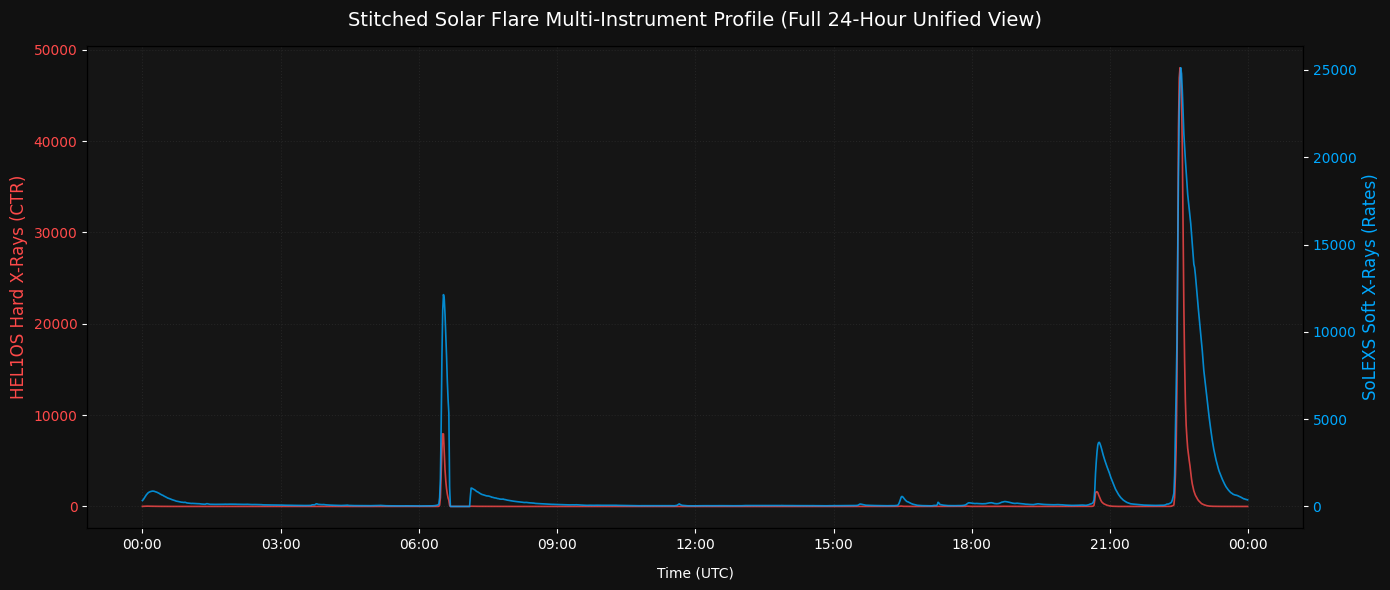

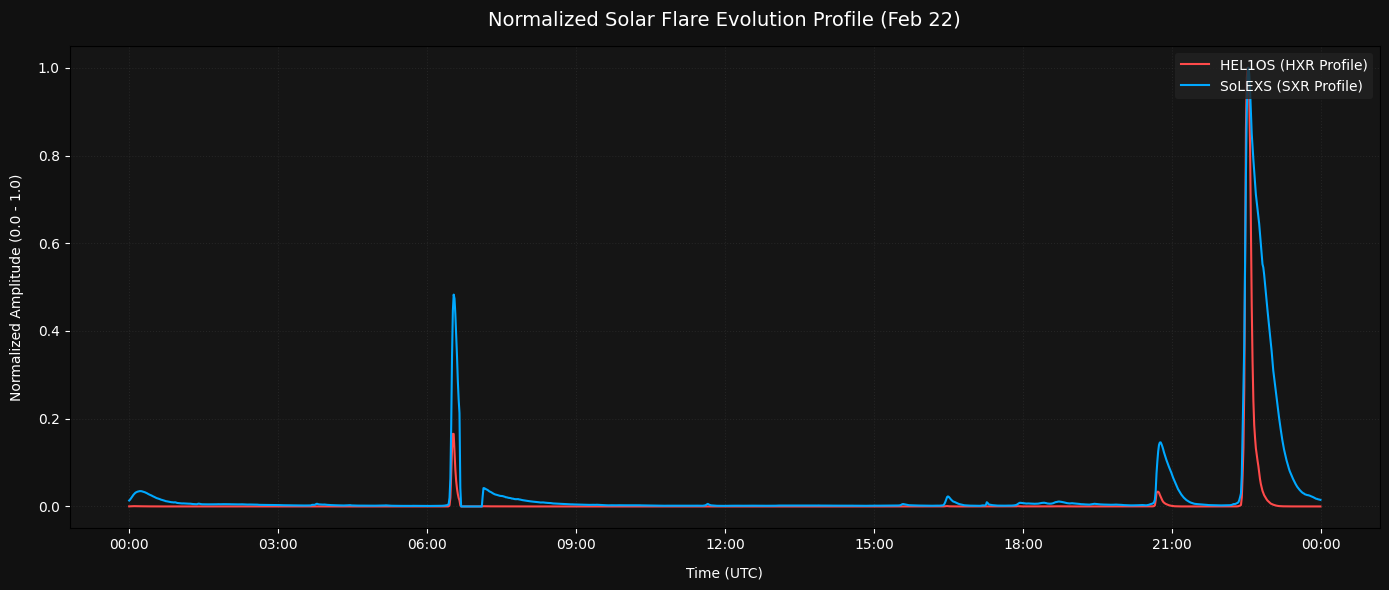

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.io import fits

# ==========================================
# ==========================================
# 1. EXPLICIT PATH CONFIGURATION (CORRECTED)
# ==========================================
hel1os_paths = [
    '/kaggle/input/datasets/ujjwalmishra101/helios22feb24-12am/2024/02/22/HLS_20240222_000006_43185sec_lev1_V111/cdte/lightcurve_cdte1.fits',
    '/kaggle/input/datasets/ujjwalmishra101/hel1os12-622feb/2024/02/22/HLS_20240222_120005_23426sec_lev1_V111/cdte/lightcurve_cdte1.fits',
    '/kaggle/input/datasets/ujjwalmishra101/hel1os-till1159-22feb/2024/02/22/HLS_20240222_183034_19758sec_lev1_V111/cdte/lightcurve_cdte1.fits'
]

solexs_path = '/kaggle/input/datasets/ujjwalmishra101/solexes-22feb24/AL1_SLX_L1_20240222_v1.0/SDD2/AL1_SOLEXS_20240222_SDD2_L1.lc/AL1_SOLEXS_20240222_SDD2_L1.lc'
# ==========================================
# 2. READ & STITCH HEL1OS FILES
# ==========================================
hel1os_series_list = []

for path in hel1os_paths:
    if not os.path.exists(path):
        print(f"Skipping missing or unmounted file path: {path}")
        continue
        
    print(f"Stitching HEL1OS segment: {os.path.basename(os.path.dirname(os.path.dirname(path)))}")
    with fits.open(path) as hdul_hel:
        df_hel_raw = pd.DataFrame(np.array(hdul_hel[1].data))
        if df_hel_raw['ISOT'].dtype == object:
            df_hel_raw['ISOT'] = df_hel_raw['ISOT'].str.decode('utf-8')
        df_hel_raw['Timestamp'] = pd.to_datetime(df_hel_raw['ISOT'])
        df_hel_raw.set_index('Timestamp', inplace=True)
        
        hel1os_ctr = df_hel_raw['CTR'].to_numpy().astype(float)
        series_chunk = pd.Series(hel1os_ctr, index=df_hel_raw.index).resample('1s').mean()
        hel1os_series_list.append(series_chunk)

if hel1os_series_list:
    hel1os_combined = pd.concat(hel1os_series_list)
    hel1os_series = hel1os_combined.groupby(hel1os_combined.index).mean().sort_index()
else:
    hel1os_series = pd.Series(dtype=float)

# ==========================================
# 3. READ & PREPROCESS SOLEXS (FIXED MJDF EPOCH)
# ==========================================
print("Processing SoLEXS Data...")
with fits.open(solexs_path) as hdul_sol:
    header = hdul_sol[1].header
    
    # FIX: Calculate proper origin from MJD using the correct base date
    if 'MJDREFI' in header:
        mjd_days = header['MJDREFI'] + header['MJDREFF']
        time_origin = pd.to_datetime(mjd_days, unit='D', origin='1858-11-17')
    else:
        time_origin = pd.to_datetime('2020-01-01')

    df_sol_raw = pd.DataFrame(np.array(hdul_sol[1].data))
    time_col = [col for col in df_sol_raw.columns if col.upper() == 'TIME'][0]
    rate_col = [col for col in df_sol_raw.columns if col.upper() in ['RATE', 'COUNTS', 'CTR']][0]
    
    raw_rates = df_sol_raw[rate_col].to_numpy()
    flattened_rates = np.array([np.sum(x) for x in raw_rates]) if isinstance(raw_rates[0], (np.ndarray, list)) else raw_rates
    
    df_sol_raw['Timestamp'] = pd.to_datetime(df_sol_raw[time_col], unit='s', origin=time_origin)
    df_sol_raw.set_index('Timestamp', inplace=True)
    solexs_series = pd.Series(flattened_rates.astype(float), index=df_sol_raw.index).resample('1s').mean().sort_index()

# ==========================================
# 4. ALIGN MASTER TIMELINE
# ==========================================
df_master = pd.DataFrame({'HEL1OS': hel1os_series, 'SoLEXS': solexs_series}).dropna(how='all').fillna(0)
df_plot = df_master.resample('1min').mean()

df_norm = df_plot.copy()
for col in ['HEL1OS', 'SoLEXS']:
    if df_norm[col].max() != df_norm[col].min():
        df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

print(f"\nUnified Full-Day Timeline Synchronized: {df_master.index[0]} to {df_master.index[-1]}")

# ==========================================
# 5. GRAPH 1: DUAL-AXIS INTENSITY PROFILE
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 6), facecolor='#111111')
ax1.set_facecolor('#151515')

ax1.set_xlabel('Time (UTC)', color='white', labelpad=10)
ax1.set_ylabel('HEL1OS Hard X-Rays (CTR)', color='#FF4A4A', fontsize=12)
ax1.plot(df_plot.index, df_plot['HEL1OS'], color='#FF4A4A', linewidth=1.2, alpha=0.8)
ax1.tick_params(axis='y', labelcolor='#FF4A4A', colors='white')
ax1.grid(True, color='#333333', linestyle=':', alpha=0.5)
ax1.tick_params(axis='x', colors='white')

ax2 = ax1.twinx()  
ax2.set_ylabel('SoLEXS Soft X-Rays (Rates)', color='#00A8FF', fontsize=12)
ax2.plot(df_plot.index, df_plot['SoLEXS'], color='#00A8FF', linewidth=1.2, alpha=0.8)
ax2.tick_params(axis='y', labelcolor='#00A8FF', colors='white')

plt.title("Stitched Solar Flare Multi-Instrument Profile (Full 24-Hour Unified View)", color='white', fontsize=14, pad=15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

# ==========================================
# 6. GRAPH 2: QUALITATIVE NORMALIZED EVOLUTION
# ==========================================
plt.figure(figsize=(14, 6), facecolor='#111111')
ax_norm = plt.axes()
ax_norm.set_facecolor('#151515')

plt.plot(df_norm.index, df_norm['HEL1OS'], color='#FF4A4A', linewidth=1.5, label='HEL1OS (HXR Profile)')
plt.plot(df_norm.index, df_norm['SoLEXS'], color='#00A8FF', linewidth=1.5, label='SoLEXS (SXR Profile)')

plt.title("Normalized Solar Flare Evolution Profile (Feb 22)", color='white', fontsize=14, pad=15)
plt.xlabel('Time (UTC)', color='white', labelpad=10)
plt.ylabel('Normalized Amplitude (0.0 - 1.0)', color='white', labelpad=10)
ax_norm.tick_params(colors='white')
ax_norm.grid(True, color='#333333', linestyle=':', alpha=0.5)
ax_norm.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.legend(facecolor='#222222', edgecolor='none', labelcolor='white', loc='upper right')
plt.tight_layout()
plt.show()